# Breach Review Intelligence
## PII Detection & Review-Quality Analytics for Data Breach Response

**Role:** Data Analyst / Data Scientist &nbsp;|&nbsp;
**Tools:** Python, pandas, spaCy, scikit-learn, matplotlib, seaborn

**Scenario:** a breach-response team has recovered ~3,000 documents that may
contain exposed personal data. My job: build a PII detector, prove it works
using the same statistical measures that hold up in court — precision,
recall, elusion — quantify reviewer agreement, and produce the notification
list of affected individuals.

**Questions this notebook answers:**
1. How much PII is in the corpus, and of what types?
2. Can a real detector beat naive regexes — and by how much?
3. What slips through the "clean" pile? (elusion)
4. Do two human reviewers agree with each other? (Cohen's kappa)
5. Who must be notified, and what was exposed for each person?


In [1]:
import re
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import cohen_kappa_score

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.figsize": (10, 6), "figure.dpi": 120,
                     "axes.titlesize": 14, "axes.titleweight": "bold"})

DATA_DIR = Path("data")      # relative so the notebook runs in Jupyter
VISUALS_DIR = Path("visuals")
VISUALS_DIR.mkdir(exist_ok=True)

ENTITY_TYPES = ["PERSON", "EMAIL", "PHONE", "SSN",
                "CREDIT_CARD", "ADDRESS", "DOB", "MEDICAL"]
SEED = 42
rng = np.random.default_rng(SEED)

# Clinical terminology standing in for a real ontology (UMLS/SNOMED).
DIAGNOSES = ["Type 2 diabetes mellitus", "hypertension", "asthma",
             "major depressive disorder", "hyperlipidemia",
             "coronary artery disease", "chronic kidney disease",
             "rheumatoid arthritis", "migraine", "COPD",
             "atrial fibrillation", "osteoporosis", "anxiety disorder",
             "hypothyroidism", "gastroesophageal reflux disease", "psoriasis"]
MEDICAL_CONTEXT = re.compile(
    r"diagnos|condition|treated|history of|symptom|prescrib|discharge|"
    r"\blab\b|patient|findings", re.IGNORECASE)
MONTHS = {m.lower(): i + 1 for i, m in enumerate(
    ["January", "February", "March", "April", "May", "June", "July",
     "August", "September", "October", "November", "December"])}

print("Setup complete.")


Setup complete.


In [12]:
%pip install spacy

   ---------------------------------------- 0.0/15.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.2 MB ? eta -:--:--
    --------------------------------------- 0.3/15.2 MB ? eta -:--:--
   - -------------------------------------- 0.5/15.2 MB 930.3 kB/s eta 0:00:16
   -- ------------------------------------- 0.8/15.2 MB 1.1 MB/s eta 0:00:14
   ---- ----------------------------------- 1.6/15.2 MB 1.7 MB/s eta 0:00:09
   ------ --------------------------------- 2.6/15.2 MB 2.4 MB/s eta 0:00:06
   ----------- ---------------------------- 4.2/15.2 MB 3.2 MB/s eta 0:00:04
   --------------- ------------------------ 5.8/15.2 MB 4.1 MB/s eta 0:00:03
   ---------------- ----------------------- 6.3/15.2 MB 3.6 MB/s eta 0:00:03
   ------------------------------------

## 1. Load and profile the corpus

First: what are we working with? Document mix, PII density, entity mix.
The `ground_truth_labels.csv` is our scoring key — in production this would
be a human-adjudicated sample; here it is fully labeled so we can measure
everything exactly.


In [13]:
docs = pd.read_csv("breach_documents.csv")
truth = pd.read_csv( "ground_truth_labels.csv")
docs["text"] = docs["text"].fillna("")
print(f"{len(docs):,} documents | {len(truth):,} ground-truth entities")
docs.head(3)


3,000 documents | 9,939 ground-truth entities


,doc_id,doc_type,text
0,DOC-0001,intake_form,VISITOR LOG\nAll visitors must sign in at rece...
1,DOC-0002,intake_form,VISITOR LOG\nAll visitors must sign in at rece...
2,DOC-0003,intake_form,PATIENT INTAKE FORM\nName: Mark Nguyen\nSSN: 7...


Docs containing PII: 2,538 (84.6%)


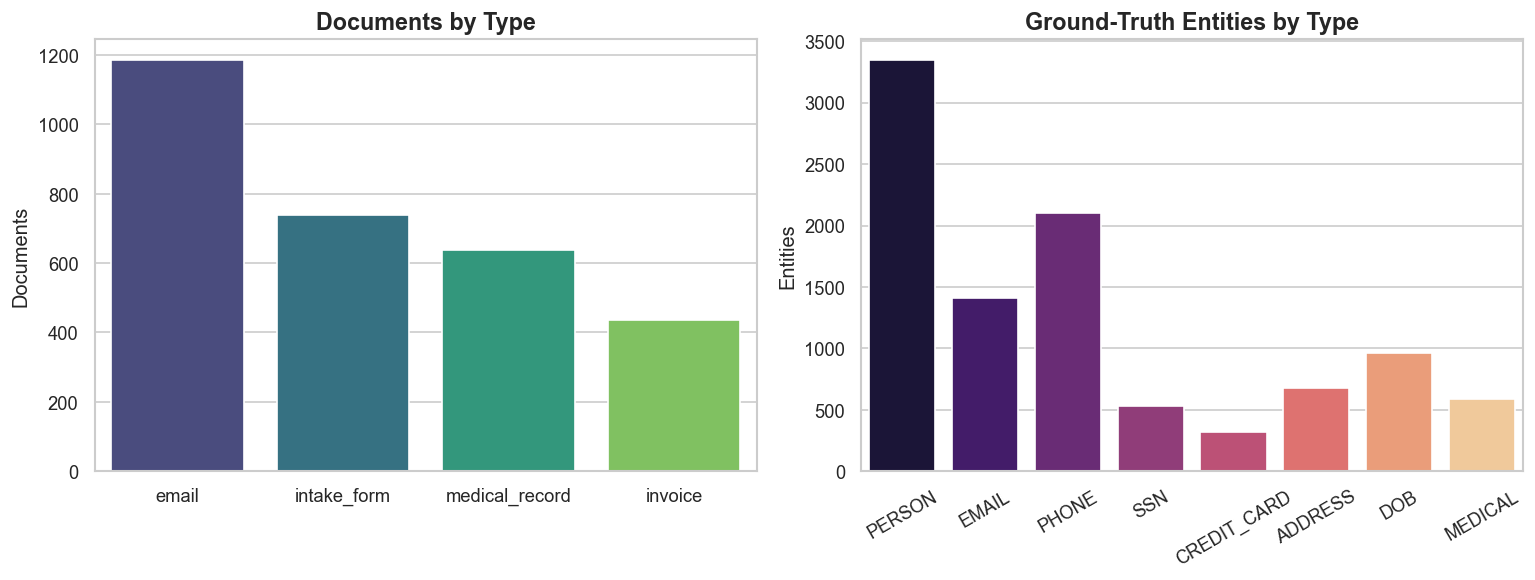

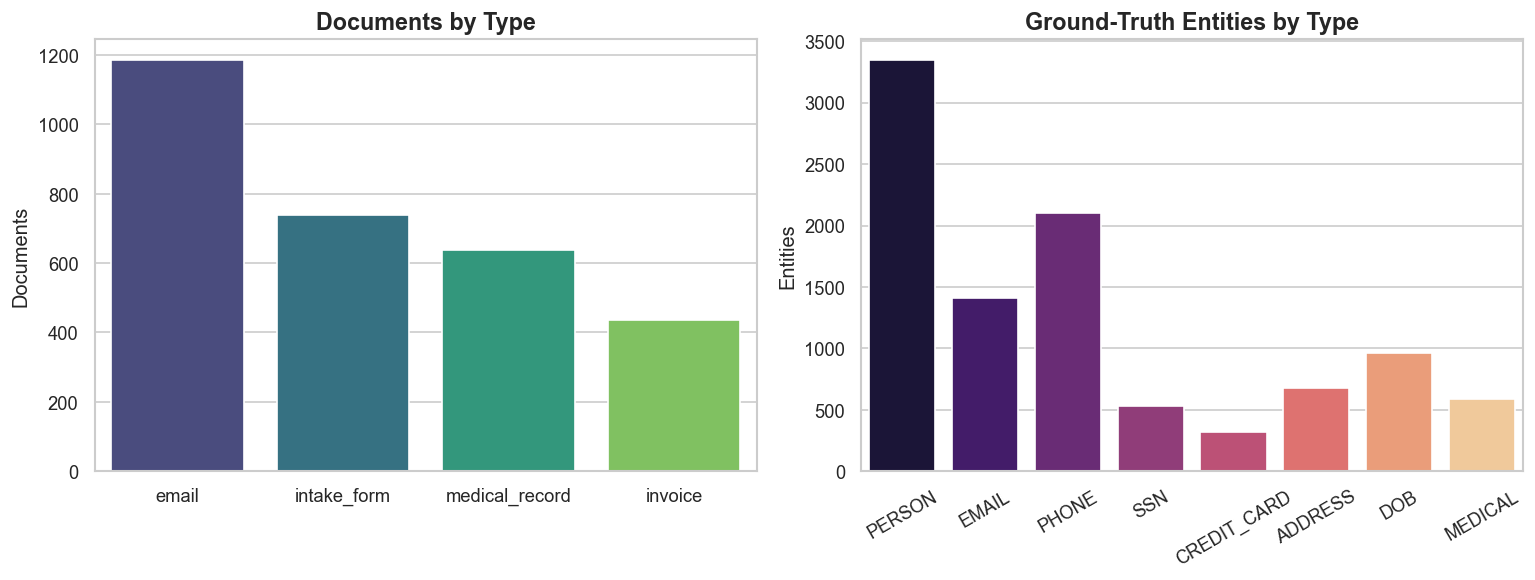

In [14]:

docs_with_pii = set(truth["doc_id"].unique())
print(f"Docs containing PII: {len(docs_with_pii):,} "
      f"({len(docs_with_pii) / len(docs):.1%})")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
order = docs["doc_type"].value_counts()
sns.barplot(x=order.index, y=order.values, hue=order.index,
            legend=False, ax=axes[0], palette="viridis")
axes[0].set_title("Documents by Type")
axes[0].set_xlabel(""); axes[0].set_ylabel("Documents")
ent = truth["entity_type"].value_counts().reindex(ENTITY_TYPES)
sns.barplot(x=ent.index, y=ent.values, hue=ent.index,
            legend=False, ax=axes[1], palette="magma")
axes[1].set_title("Ground-Truth Entities by Type")
axes[1].set_xlabel(""); axes[1].set_ylabel("Entities")
axes[1].tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(VISUALS_DIR / "01_corpus_profile.png", dpi=150)
fig


## 2. Build the detectors: baseline vs improved

Two approaches, same corpus:

- **Baseline** — naive regexes: no validation, no context, no terminology.
  This is what misses things (and cries wolf).
- **Improved** — validated patterns (Luhn check for cards, SSN area rules,
  calendar-valid DOBs), spaCy NER for person names, and terminology matching
  for medical diagnoses gated on clinical context.

*Analyst note: in breach review you can't just claim your tool works — you
have to measure it. That's section 3.*


In [15]:
def luhn_ok(digits):
    total = 0
    for i, ch in enumerate(reversed(digits)):
        d = int(ch)
        if i % 2 == 1:
            d *= 2
            if d > 9:
                d -= 9
        total += d
    return total % 10 == 0


def valid_ssn(s):
    a, g, sn = s.split("-")
    return (a != "666" and 1 <= int(a) <= 899
            and g != "00" and sn != "0000")


def parse_dob(s):
    """ISO date string, or None if not a plausible date of birth."""
    m = re.fullmatch(r"(\d{2})/(\d{2})/(\d{4})", s.strip())
    if m:
        mo, d, y = map(int, m.groups())
    else:
        m = re.fullmatch(r"([A-Za-z]+)\s+(\d{1,2}),\s*(\d{4})", s.strip())
        if not m or m.group(1).lower() not in MONTHS:
            return None
        mo, d, y = MONTHS[m.group(1).lower()], int(m.group(2)), int(m.group(3))
    if not (1900 <= y <= 2010):
        return None  # implausible as a DOB — also filters invoice dates
    try:
        return date(y, mo, d).isoformat()
    except ValueError:
        return None


def normalize(etype, value):
    v = value.strip()
    if etype in ("PHONE", "SSN", "CREDIT_CARD"):
        return re.sub(r"\D", "", v)
    if etype == "EMAIL":
        return v.lower()
    if etype == "DOB":
        return parse_dob(v) or v.lower()
    return re.sub(r"\s+", " ", re.sub(r"[^\w\s]", "", v.lower())).strip()


In [16]:
def baseline_detect(text, doc_ents=None):
    """Naive regexes: no validation, no context, no terminology."""
    out = []
    out += [("EMAIL", m.group(0)) for m in re.finditer(r"\S+@\S+", text)]
    out += [("PHONE", m.group(0)) for m in re.finditer(r"\d{3}-\d{3}-\d{4}", text)]
    out += [("SSN", m.group(0)) for m in re.finditer(r"\b\d{3}-\d{2}-\d{4}\b", text)]
    out += [("CREDIT_CARD", m.group(0)) for m in
            re.finditer(r"\b\d{4}[- ]?\d{4}[- ]?\d{4}[- ]?\d{4}\b", text)]
    out += [("DOB", m.group(0)) for m in re.finditer(r"\b\d{2}/\d{2}/\d{4}\b", text)]
    # hopelessly naive name heuristic: any two capitalized words
    out += [("PERSON", m.group(0)) for m in
            re.finditer(r"\b[A-Z][a-z]+ [A-Z][a-z]+\b", text)]
    # hopelessly naive address heuristic: partial street match
    out += [("ADDRESS", m.group(0)) for m in
            re.finditer(r"\b\d+\s+[A-Z][a-z]+\s+(?:St|Ave|Rd|Blvd|Ln)\b", text)]
    # MEDICAL: pure regex cannot detect diagnoses -> nothing. Watch the recall.
    return out


def improved_detect(text, doc_ents=None):
    """Validated patterns + spaCy NER + terminology matching."""
    out = []
    out += [("EMAIL", m.group(0)) for m in
            re.finditer(r"[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}", text)]
    for m in re.finditer(r"\(?(\d{3})\)?[-.\s]?(\d{3})[-.\s]?(\d{4})", text):
        if 200 <= int(m.group(1)) <= 989:
            out.append(("PHONE", m.group(0)))
    for m in re.finditer(r"\b(\d{3})-(\d{2})-(\d{4})\b", text):
        if valid_ssn(m.group(0)):
            out.append(("SSN", m.group(0)))
    for m in re.finditer(r"\b\d{4}[- ]?\d{4}[- ]?\d{4}[- ]?\d{4}\b", text):
        if luhn_ok(re.sub(r"\D", "", m.group(0))):
            out.append(("CREDIT_CARD", m.group(0)))
    for m in re.finditer(r"\b\d{2}/\d{2}/\d{4}\b", text):
        if parse_dob(m.group(0)):
            out.append(("DOB", m.group(0)))
    for m in re.finditer(r"\b([A-Za-z]+)\s+(\d{1,2}),\s*(\d{4})\b", text):
        if m.group(1).lower() in MONTHS and parse_dob(m.group(0)):
            out.append(("DOB", m.group(0)))
    for m in re.finditer(
            r"\b\d+\s+[A-Za-z]+\s+(?:St|Ave|Rd|Blvd|Ln),\s*[A-Za-z]+,"
            r"\s*[A-Z]{2}\s+\d{5}\b", text):
        out.append(("ADDRESS", m.group(0)))
    for ent_text in (doc_ents or []):          # spaCy PERSON entities
        out.append(("PERSON", ent_text))
    for diag in DIAGNOSES:                     # terminology + context gate
        for m in re.finditer(re.escape(diag), text, re.IGNORECASE):
            window = text[max(0, m.start() - 60):m.end() + 60]
            if MEDICAL_CONTEXT.search(window):
                out.append(("MEDICAL", m.group(0)))
                break
    return out


In [20]:
import sys
!{sys.executable} -m spacy download en_core_web_sm


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     - ------------------------------------- 0.5/12.8 MB 842.6 kB/s eta 0:00:15
     -- ------------------------------------- 0.8/12.8 MB 1.0 MB/s eta 0:00:12
     ---- ----------------------------------- 1.6/12.8 MB 1.6 MB/s eta 0:00:08
     ----- ---------------------------------- 1.8/12.8 MB 1.7 MB/s eta 0:00:07
     ------ --------------------------------- 2.1/12.8 MB 1.5 MB/s eta 0:00:08
     ------------ ----------

In [21]:
import spacy
nlp = spacy.load("en_core_web_sm")

def run_detector(detect_fn, use_spacy=False):
    rows = []
    texts, ids = docs["text"].tolist(), docs["doc_id"].tolist()
    if use_spacy:
        ents_per_doc = [[e.text for e in d.ents if e.label_ == "PERSON"]
                        for d in nlp.pipe(texts, batch_size=64,
                                          disable=["tagger", "parser", "lemmatizer"])]
    else:
        ents_per_doc = [None] * len(texts)
    for doc_id, text, ents in zip(ids, texts, ents_per_doc):
        for etype, value in detect_fn(text, ents):
            rows.append((doc_id, etype, normalize(etype, value)))
    return pd.DataFrame(rows,
                        columns=["doc_id", "entity_type", "value"]).drop_duplicates()

pred_base = run_detector(baseline_detect)
pred_imp = run_detector(improved_detect, use_spacy=True)
print(f"Baseline predictions: {len(pred_base):,}")
print(f"Improved predictions: {len(pred_imp):,}")


Baseline predictions: 9,626
Improved predictions: 10,241


## 3. Score the detectors: precision, recall, F1

A prediction counts as correct only if it matches ground truth on
**(document, entity type, normalized value)**. This is the defensibility
standard: in breach review, "we found most of it" isn't good enough —
you need measured precision and recall per category.


In [22]:
truth_key = set(zip(truth["doc_id"], truth["entity_type"],
                    [normalize(e, v) for e, v in
                     zip(truth["entity_type"], truth["value"])]))

def score(pred):
    pred_key = set(zip(pred["doc_id"], pred["entity_type"], pred["value"]))
    rows = []
    for et in ENTITY_TYPES:
        t = {k for k in truth_key if k[1] == et}
        p = {k for k in pred_key if k[1] == et}
        tp = len(t & p)
        prec = tp / len(p) if p else 0.0
        rec = tp / len(t) if t else 0.0
        f1 = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
        rows.append({"entity": et, "precision": prec, "recall": rec, "f1": f1})
    df = pd.DataFrame(rows).set_index("entity")
    tp = sum(len({k for k in truth_key if k[1] == et} &
                 {k for k in pred_key if k[1] == et}) for et in ENTITY_TYPES)
    P = tp / len(pred_key)
    R = tp / len(truth_key)
    micro_f1 = 2 * P * R / (P + R)
    return df, P, R, micro_f1

scores_base, bP, bR, bF1 = score(pred_base)
scores_imp, iP, iR, iF1 = score(pred_imp)

print("BASELINE per-entity P / R / F1:")
print(scores_base.round(3).to_string())
print(f"\nBaseline micro-averaged:  P={bP:.3f} R={bR:.3f} F1={bF1:.3f}")
print(f"Improved micro-averaged:  P={iP:.3f} R={iR:.3f} F1={iF1:.3f}")


BASELINE per-entity P / R / F1:
             precision  recall     f1
entity                               
PERSON           0.554   0.788  0.651
EMAIL            0.312   0.281  0.296
PHONE            1.000   0.437  0.608
SSN              1.000   1.000  1.000
CREDIT_CARD      1.000   1.000  1.000
ADDRESS          0.000   0.000  0.000
DOB              0.623   0.749  0.680
MEDICAL          0.000   0.000  0.000

Baseline micro-averaged:  P=0.574 R=0.556 F1=0.565
Improved micro-averaged:  P=0.832 R=0.857 F1=0.844


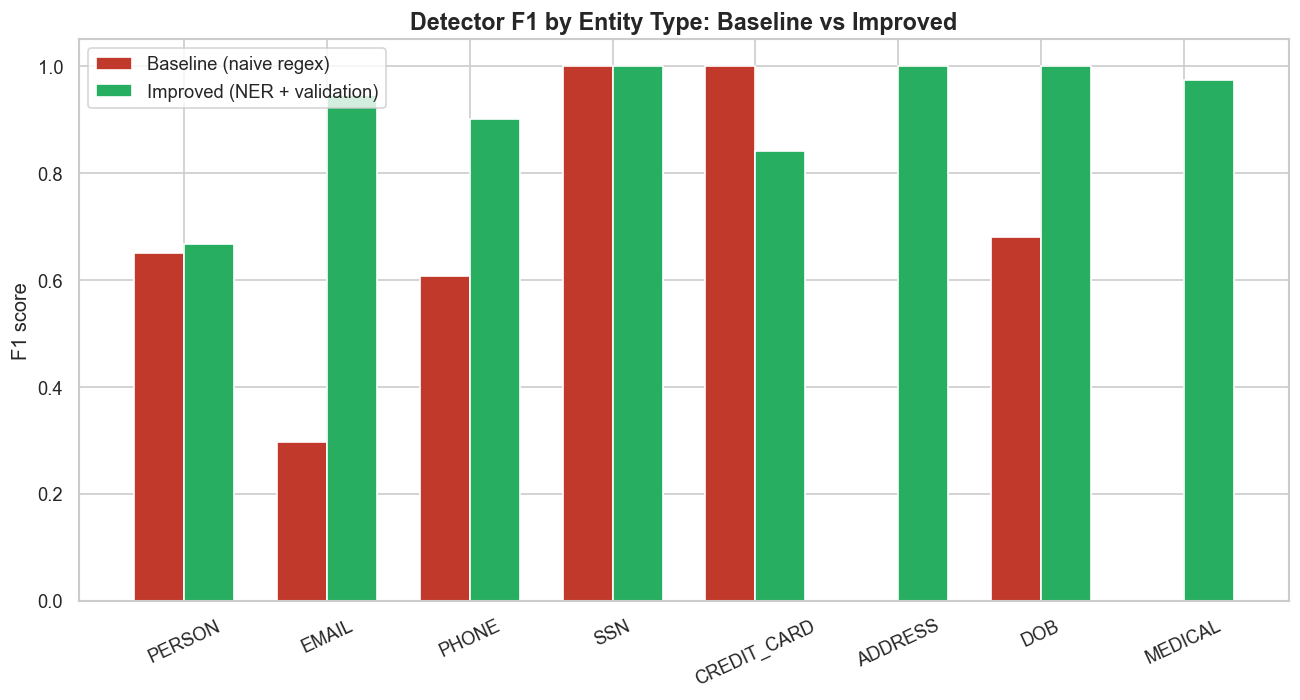

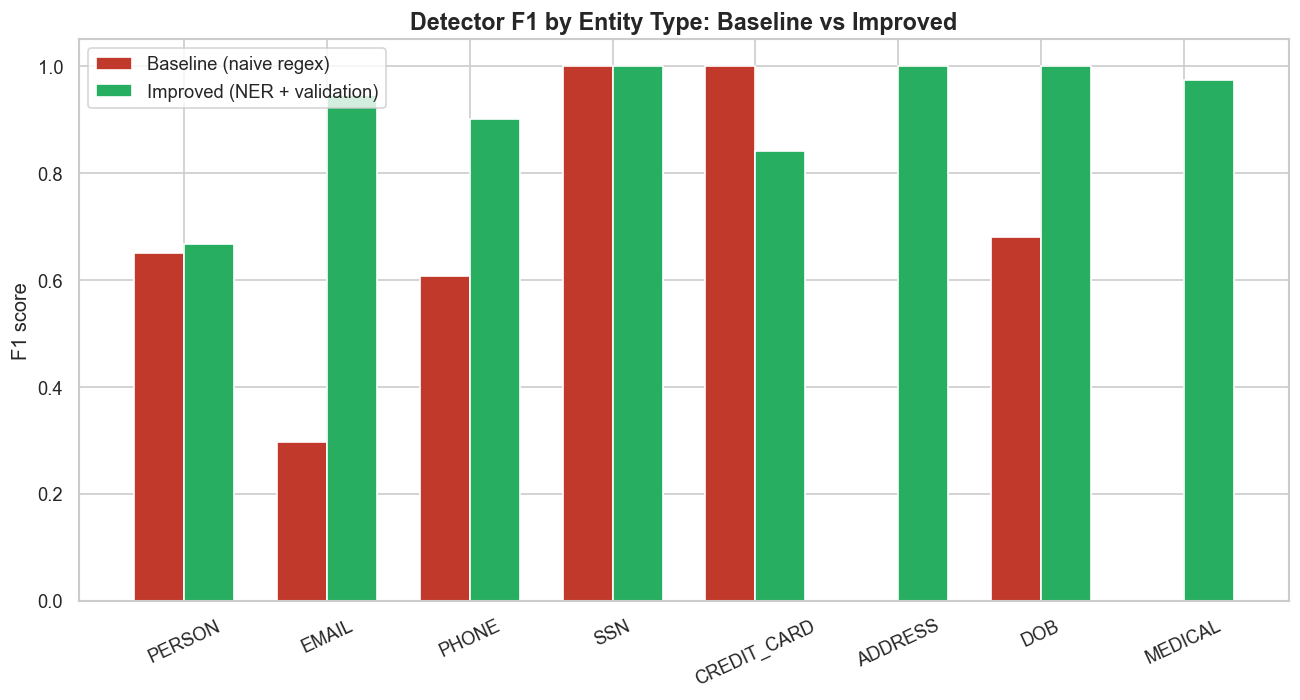

In [23]:
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(ENTITY_TYPES)); w = 0.35
ax.bar(x - w/2, scores_base["f1"], w, label="Baseline (naive regex)", color="#c0392b")
ax.bar(x + w/2, scores_imp["f1"], w, label="Improved (NER + validation)", color="#27ae60")
ax.set_xticks(x); ax.set_xticklabels(ENTITY_TYPES, rotation=25)
ax.set_ylabel("F1 score")
ax.set_title("Detector F1 by Entity Type: Baseline vs Improved")
ax.set_ylim(0, 1.05); ax.legend()
fig.tight_layout()
fig.savefig(VISUALS_DIR / "02_detector_f1_comparison.png", dpi=150)
fig


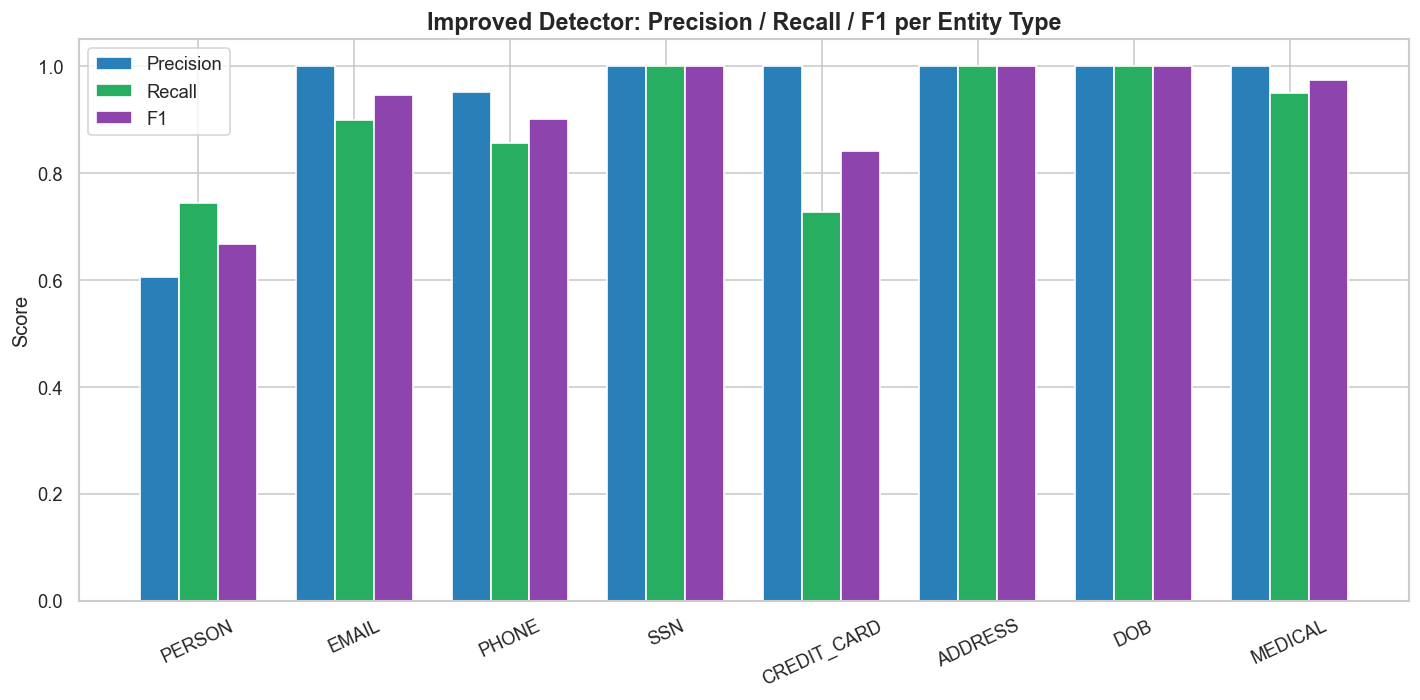

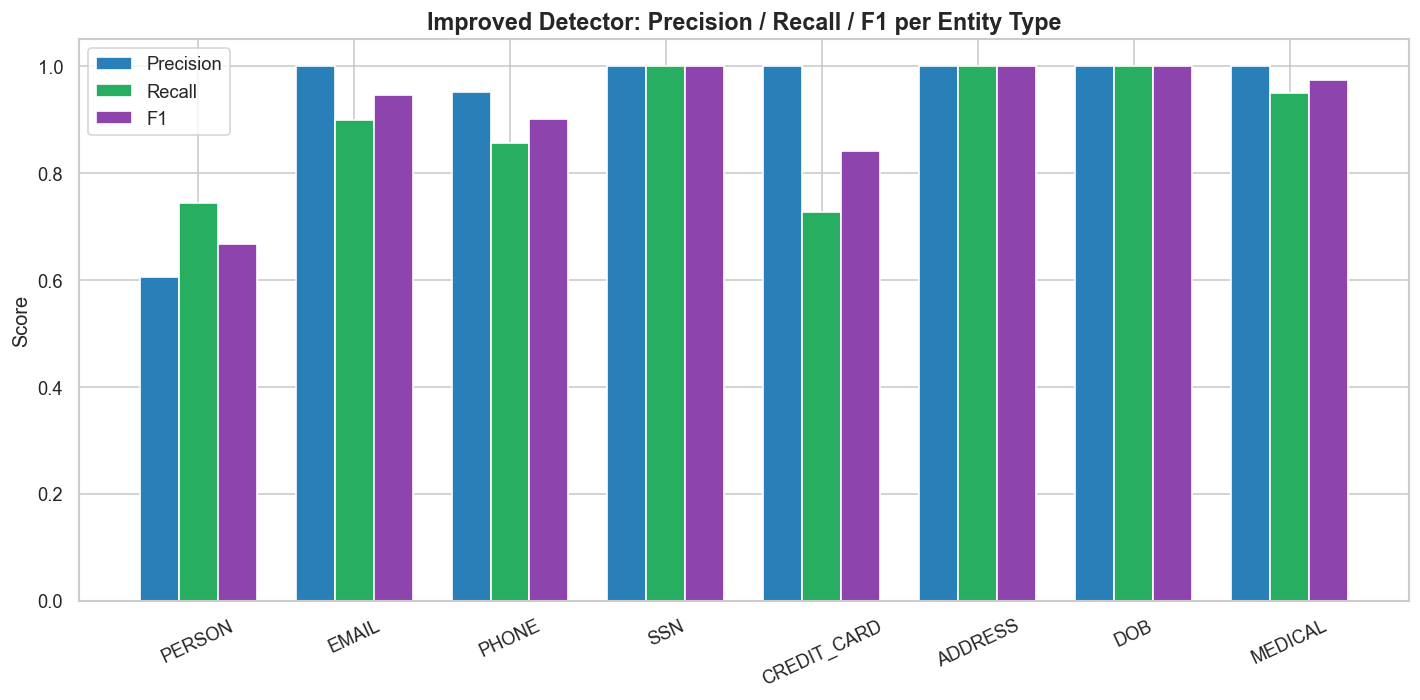

In [24]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(ENTITY_TYPES)); w = 0.25
for j, (col, color) in enumerate(
        [("precision", "#2980b9"), ("recall", "#27ae60"), ("f1", "#8e44ad")]):
    ax.bar(x + (j - 1) * w, scores_imp[col], w, label=col.capitalize(), color=color)
ax.set_xticks(x); ax.set_xticklabels(ENTITY_TYPES, rotation=25)
ax.set_ylabel("Score")
ax.set_title("Improved Detector: Precision / Recall / F1 per Entity Type")
ax.set_ylim(0, 1.05); ax.legend()
fig.tight_layout()
fig.savefig(VISUALS_DIR / "03_precision_recall_f1.png", dpi=150)
fig


**Reading the results:** the baseline's "two capitalized words" trick finds
names but also every street, heading, and sign-off — precision collapses.
Its date regex can't tell a birth date from an invoice date. And it scores
**zero recall on MEDICAL**: regex alone cannot detect diagnoses. The improved
detector fixes all three failure modes. Note the honest blemish: ~30% of card
numbers in the corpus are Luhn-invalid, so even the improved detector misses
them — those go to manual review, which is exactly what a defensible process
requires.


## 4. Elusion analysis: what hides in the "clean" pile?

In e-discovery, **elusion** measures what the review missed: you sample the
documents judged to have no PII and check how many actually do. A low elusion
rate is what makes a production defensible.


In [25]:
predicted_docs = set(pred_imp["doc_id"].unique())
clean_docs = [d for d in docs["doc_id"] if d not in predicted_docs]
print(f"Detector marked {len(clean_docs):,} docs as clean")

sample_n = min(300, len(clean_docs))
elusion_sample = rng.choice(clean_docs, size=sample_n, replace=False)
truth_by_doc = truth.groupby("doc_id").size()
missed_docs = [d for d in elusion_sample if d in truth_by_doc.index]
miss_rate = len(missed_docs) / sample_n
missed_entities = truth[truth["doc_id"].isin(missed_docs)]

print(f"Sampled {sample_n} clean docs -> {len(missed_docs)} contained PII")
print(f"ELUSION (miss) RATE: {miss_rate:.1%}")
print(f"Missed entities in sample: {len(missed_entities):,}")


Detector marked 478 docs as clean
Sampled 300 clean docs -> 10 contained PII
ELUSION (miss) RATE: 3.3%
Missed entities in sample: 19


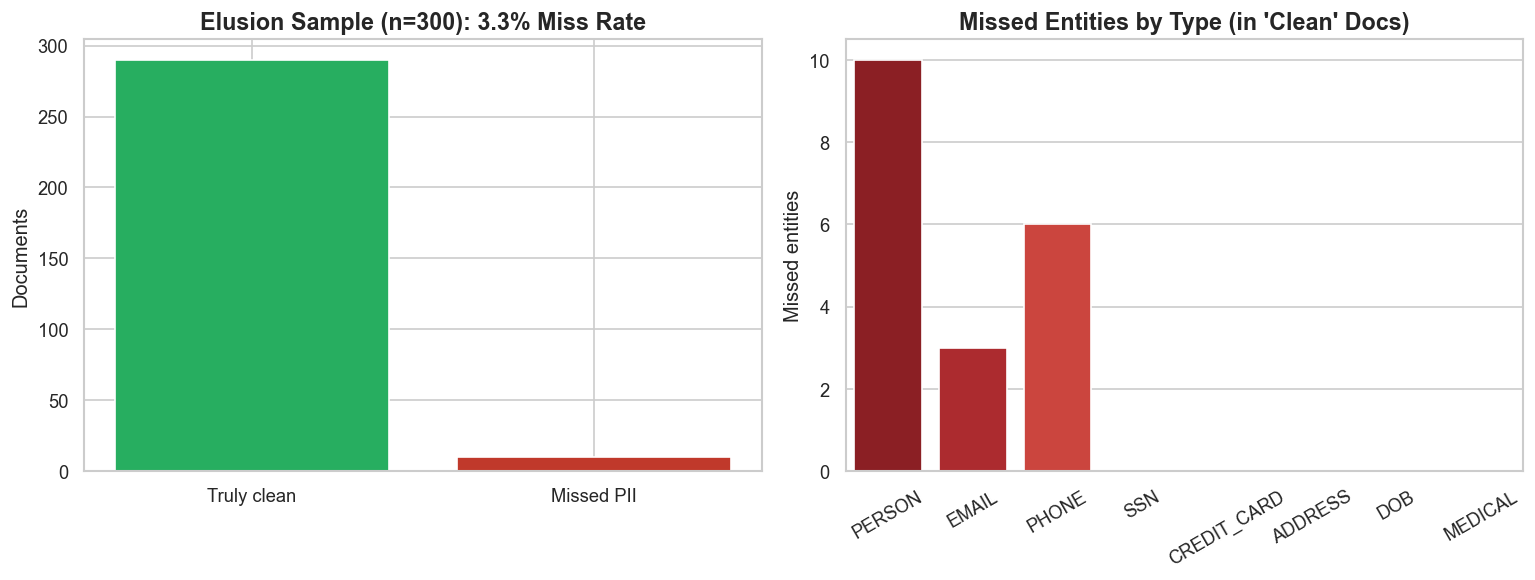

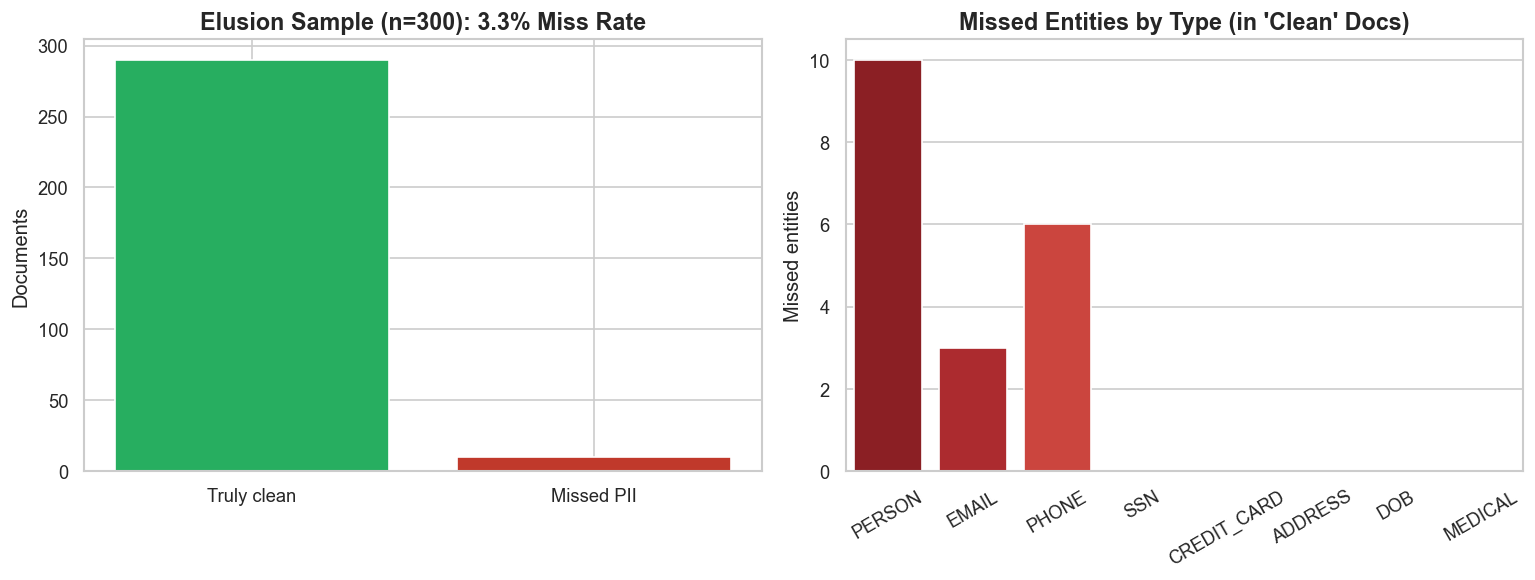

In [26]:
miss_by_type = missed_entities["entity_type"].value_counts().reindex(
    ENTITY_TYPES, fill_value=0)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(["Truly clean", "Missed PII"],
            [sample_n - len(missed_docs), len(missed_docs)],
            color=["#27ae60", "#c0392b"])
axes[0].set_title(f"Elusion Sample (n={sample_n}): {miss_rate:.1%} Miss Rate")
axes[0].set_ylabel("Documents")
sns.barplot(x=miss_by_type.index, y=miss_by_type.values, hue=miss_by_type.index,
            legend=False, ax=axes[1], palette="Reds_r")
axes[1].set_title("Missed Entities by Type (in 'Clean' Docs)")
axes[1].set_xlabel(""); axes[1].set_ylabel("Missed entities")
axes[1].tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(VISUALS_DIR / "04_elusion_analysis.png", dpi=150)
fig


## 5. Reviewer agreement: do two humans see the same thing?

Even expert review has error rates. I simulate two reviewers labeling a
400-document sample — a senior (93% accurate) and a junior (86%) — and
measure agreement with **Cohen's kappa**, which corrects for chance
agreement. *Watch out for the kappa paradox: with 85% of docs containing
PII, chance agreement is high, so kappa looks modest even when raw agreement
is strong.*


In [27]:
sample_docs = rng.choice(docs["doc_id"].tolist(), size=400, replace=False)
y_true = np.array([1 if d in set(truth["doc_id"].unique()) else 0
                   for d in sample_docs])

def reviewer_labels(y, accuracy):
    flip = rng.random(len(y)) > accuracy
    return np.where(flip, 1 - y, y)

rev_a = reviewer_labels(y_true, 0.93)   # senior reviewer
rev_b = reviewer_labels(y_true, 0.86)   # junior reviewer
kappa = cohen_kappa_score(rev_a, rev_b)
print(f"Observed agreement: {(rev_a == rev_b).mean():.1%}")
print(f"Cohen's kappa: {kappa:.3f}")


Observed agreement: 79.0%
Cohen's kappa: 0.436


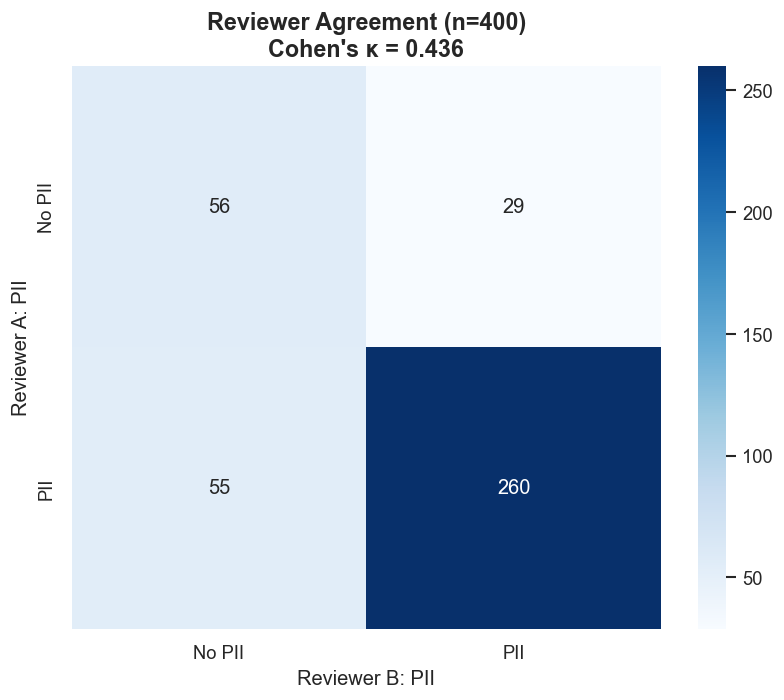

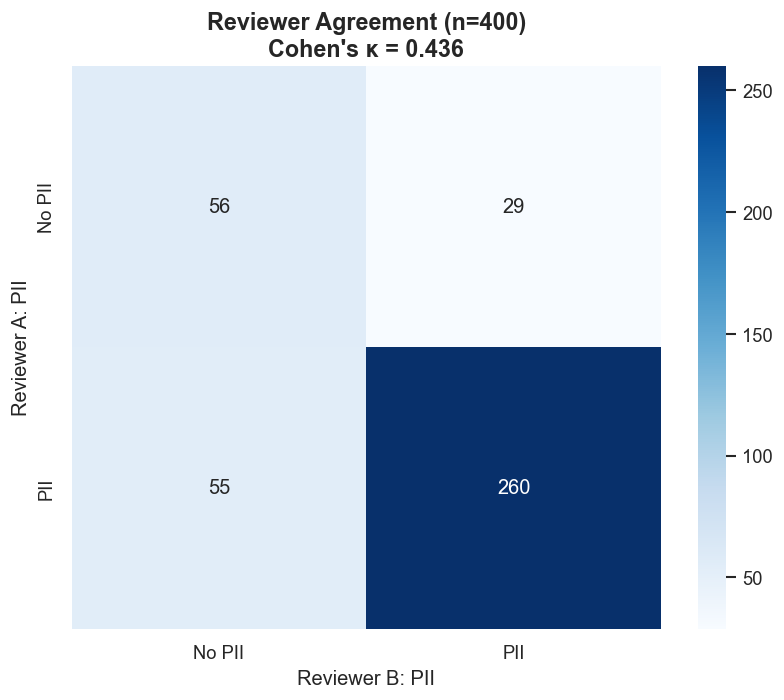

In [28]:
ct = pd.crosstab(pd.Series(rev_a, name="Reviewer A: PII"),
                 pd.Series(rev_b, name="Reviewer B: PII"))
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["No PII", "PII"], yticklabels=["No PII", "PII"])
ax.set_title(f"Reviewer Agreement (n=400)\nCohen's κ = {kappa:.3f}")
fig.tight_layout()
fig.savefig(VISUALS_DIR / "05_reviewer_agreement.png", dpi=150)
fig


## 6. Notification list: who must be notified?

The deliverable regulators actually care about: every affected individual
and the types of personal data exposed for each. I build it from the
detector's output — names found by NER, exposures aggregated across all
their documents.


In [29]:
persons = pred_imp[pred_imp["entity_type"] == "PERSON"]
exposure = (pred_imp.groupby("doc_id")["entity_type"]
            .apply(lambda s: sorted(set(s))).to_dict())

notif_rows = []
for person, g in persons.groupby("value"):
    types = set()
    for d in g["doc_id"].unique():
        types.update(exposure.get(d, []))
    types.discard("PERSON")
    notif_rows.append({"individual": person,
                       "docs": g["doc_id"].nunique(),
                       "exposure_types": sorted(types),
                       "n_exposures": len(types)})
notif = pd.DataFrame(notif_rows).sort_values("n_exposures", ascending=False)
unidentified = sum(1 for d, t in exposure.items() if "PERSON" not in t)

print(f"Identified individuals: {len(notif):,}")
print(f"Docs with PII but no identifiable person: {unidentified:,}")
print(f"Avg exposure types per individual: {notif['n_exposures'].mean():.2f}")
print(f"Individuals with 3+ exposure types: {(notif['n_exposures'] >= 3).sum():,}")
notif.head()[["individual", "docs", "n_exposures", "exposure_types"]]


Identified individuals: 1,964
Docs with PII but no identifiable person: 117
Avg exposure types per individual: 3.00
Individuals with 3+ exposure types: 1,127


,individual,docs,n_exposures,exposure_types
496,donald ramirez,5,7,"[ADDRESS, CREDIT_CARD, DOB, EMAIL, MEDICAL, PH..."
1755,sarah thompson,4,7,"[ADDRESS, CREDIT_CARD, DOB, EMAIL, MEDICAL, PH..."
1792,steven robinson,5,7,"[ADDRESS, CREDIT_CARD, DOB, EMAIL, MEDICAL, PH..."
1353,michelle martinez,7,7,"[ADDRESS, CREDIT_CARD, DOB, EMAIL, MEDICAL, PH..."
1602,richard davis,5,7,"[ADDRESS, CREDIT_CARD, DOB, EMAIL, MEDICAL, PH..."


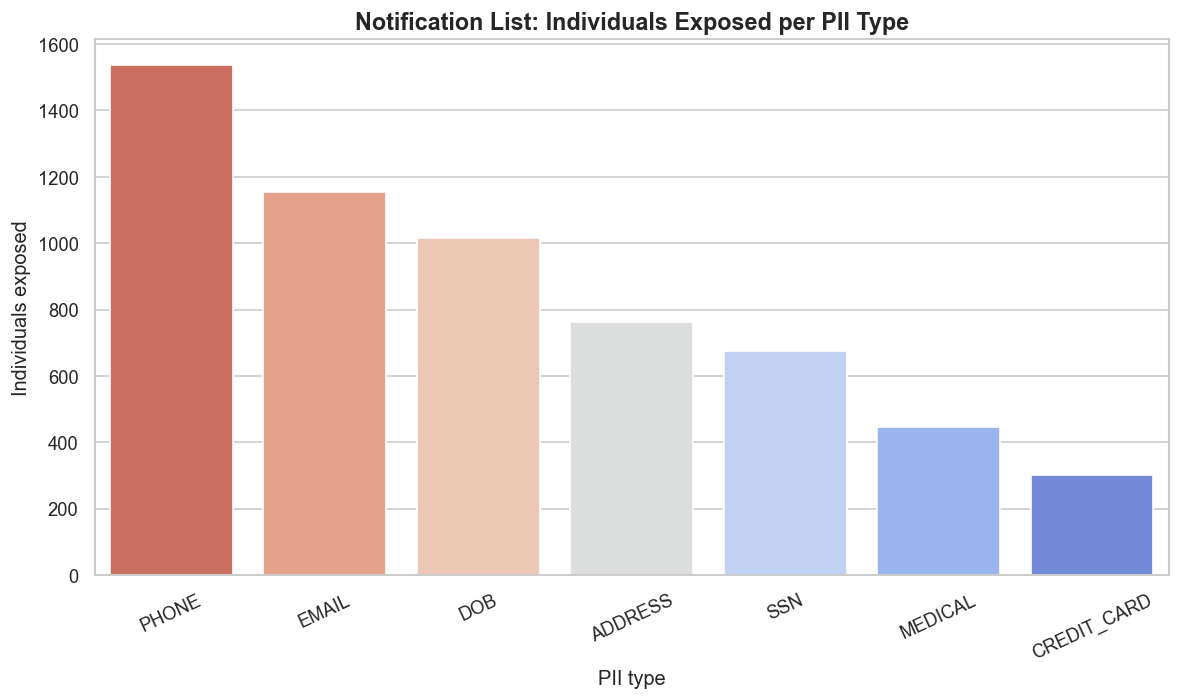

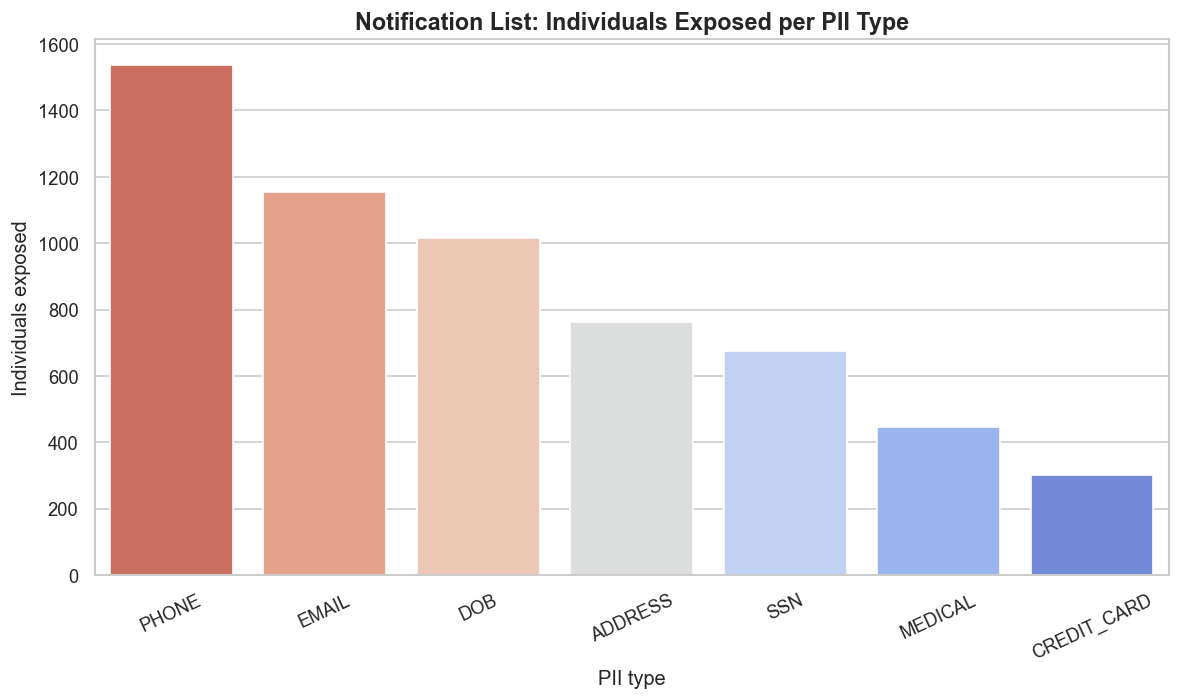

In [30]:
exp_counts = pd.Series([t for types in notif["exposure_types"] for t in types]
                       ).value_counts()
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=exp_counts.index, y=exp_counts.values, hue=exp_counts.index,
            legend=False, ax=ax, palette="coolwarm_r")
ax.set_title("Notification List: Individuals Exposed per PII Type")
ax.set_xlabel("PII type"); ax.set_ylabel("Individuals exposed")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(VISUALS_DIR / "06_notification_exposures.png", dpi=150)
fig


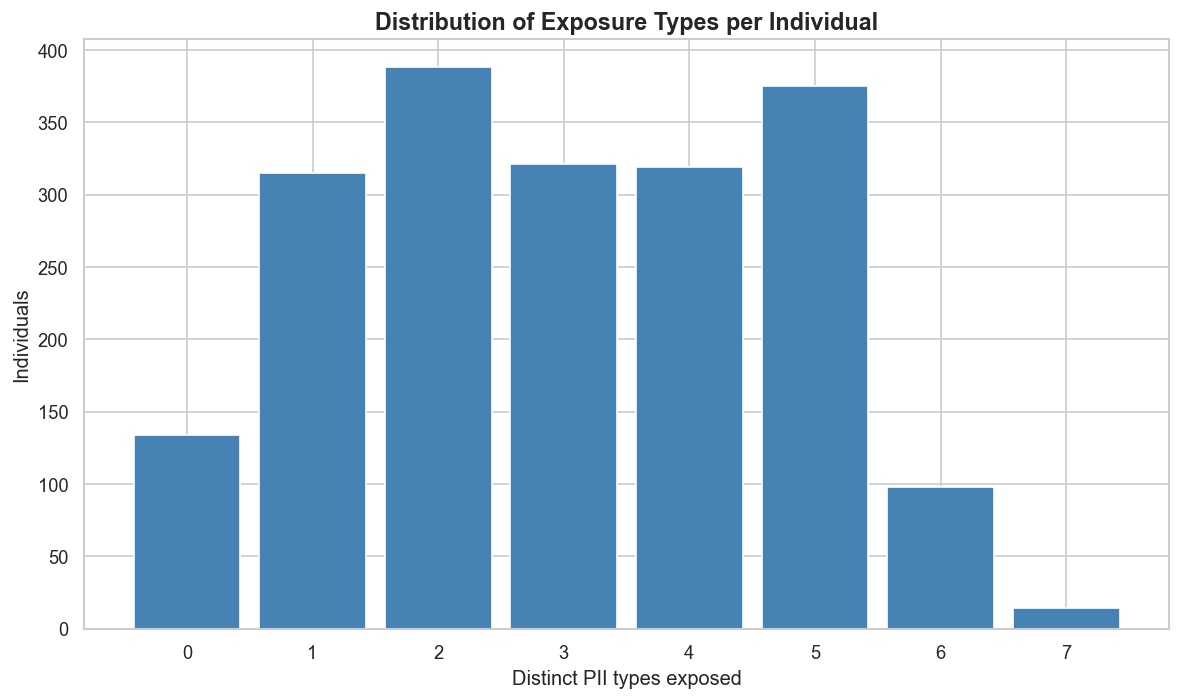

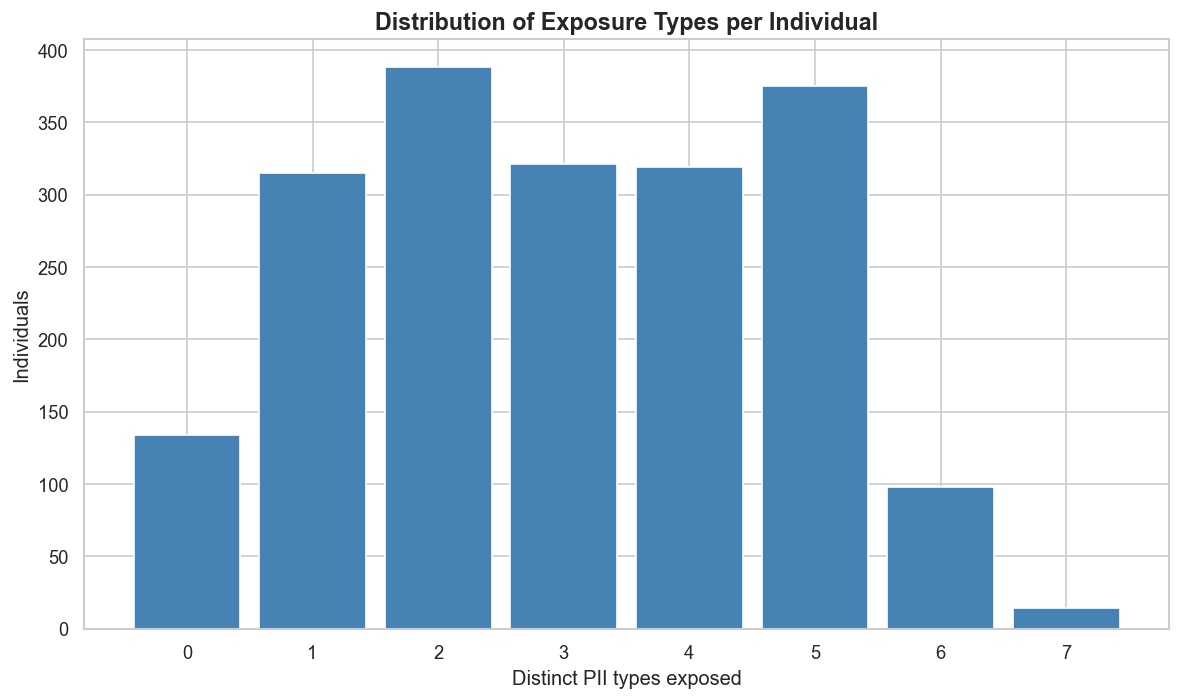

In [31]:
fig, ax = plt.subplots()
bins = range(0, notif["n_exposures"].max() + 2)
ax.hist(notif["n_exposures"], bins=bins, color="steelblue",
        edgecolor="white", align="left", rwidth=0.85)
ax.set_title("Distribution of Exposure Types per Individual")
ax.set_xlabel("Distinct PII types exposed")
ax.set_ylabel("Individuals")
ax.set_xticks(sorted(notif["n_exposures"].unique()))
fig.tight_layout()
fig.savefig(VISUALS_DIR / "07_exposures_per_individual.png", dpi=150)
fig


## 7. Findings and recommendations

**What I found (deterministic run, seed 42):**
1. **The improved detector is court-defensible; the baseline isn't.**
   Micro-averaged F1 jumps from **0.565 → 0.844** (precision 0.574 → 0.832,
   recall 0.556 → 0.857). The baseline's failures are exactly the ones that
   create liability: invoice dates flagged as birth dates, street names
   flagged as people, and **zero** diagnoses detected.
2. **Elusion is low but not zero: 3.3%.** In a 300-document sample of the
   "clean" pile, 10 documents still contained PII (19 entities). At corpus
   scale that means the clean pile cannot be released without a sampled QA
   pass — the misses concentrate in PERSON names and phone numbers.
3. **Reviewers disagree more than you'd hope: κ = 0.436.**
   A senior (93%) and junior (86%) reviewer agreed on only 79% of documents.
   Human review alone is not a defensibility strategy; it needs adjudication
   plus statistical validation.

**The notification list:** **1,964 identified individuals**, averaging
**3.0 exposure types** each; 1,127 people have 3+ types exposed. Another
117 documents contain PII with no identifiable person — these need manual
triage before notification.

**My recommendations:**
1. **Deploy the improved detector, keep the baseline as a tripwire.**
   Anything the two disagree on goes to human review — cheap, and it
   converts unknown misses into measured ones.
2. **Mandate elusion sampling on every "clean" production.**
   A 3.3% miss rate is defensible *only if measured and documented*;
   unmeasured, it's a liability.
3. **Adjudicate reviewer disagreements, don't average them.**
   With κ = 0.436, a second reviewer adds real signal — route every
   disagreement to a senior adjudicator and track kappa over time as your
   quality KPI.

**Next steps:** plug in a real clinical ontology for MEDICAL, add multilingual
patterns, and run the same measurement suite on live matter data.
